In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [ ]:
import sklearn.discriminant_analysis as DA
import matplotlib.pyplot as plt

Fisher=DA.LinearDiscriminantAnalysis()

N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

print(f"Training samples: {len(Train_Sample)}")
print(f"Testing samples: {len(Test_Sample)}")
print(f"Test signal samples: {len(Test_sig)}")
print(f"Test background samples: {len(Test_bkg)}")


Training samples: 4000000
Testing samples: 999999
Test signal samples: 458232
Test background samples: 541767


In [ ]:
Fisher.fit(X_Train,y_Train)

print("LDA Classifier trained successfully.")


LDA Classifier trained successfully.


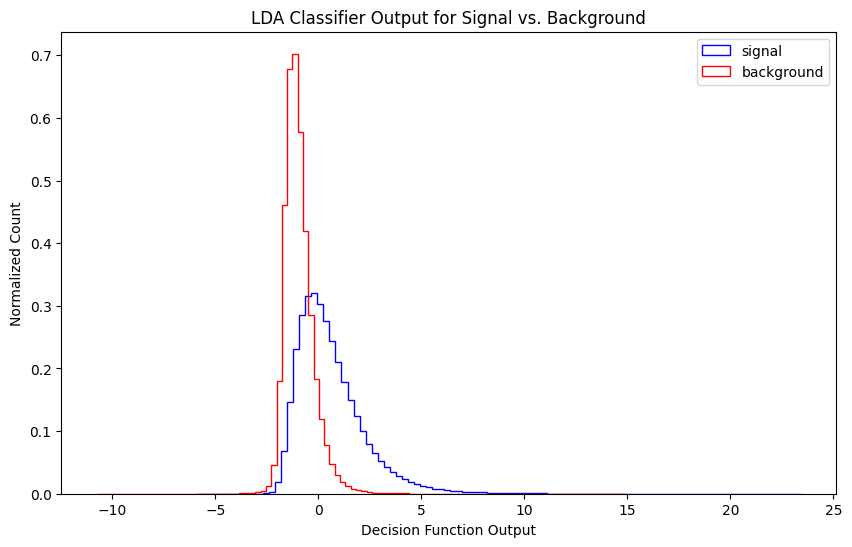

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True, density=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True, density=True)
plt.xlabel("Decision Function Output")
plt.ylabel("Normalized Count")
plt.title("LDA Classifier Output for Signal vs. Background")
plt.legend(loc='upper right')
plt.show()


 problem 3 part a

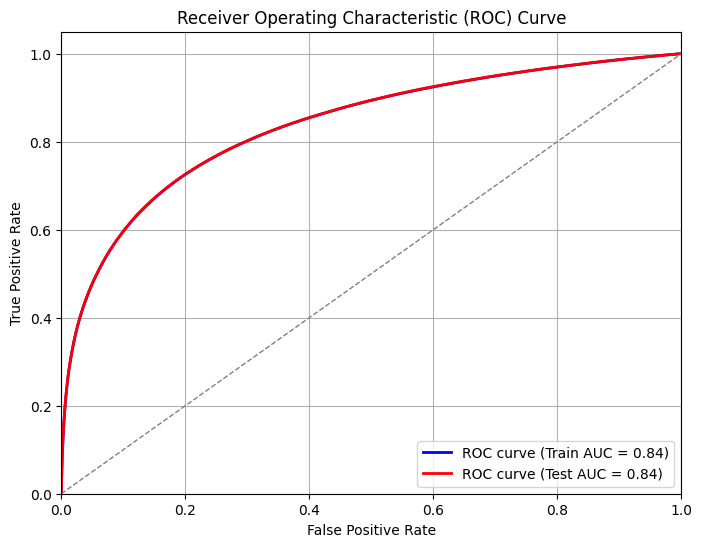

Training AUC: 0.8362
Testing AUC: 0.8364


In [ ]:
from sklearn.metrics import roc_curve, auc


y_train_pred_proba = Fisher.decision_function(X_Train)
y_test_pred_proba = Fisher.decision_function(X_Test)


fpr_train, tpr_train, _ = roc_curve(y_Train, y_train_pred_proba)
auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_Test, y_test_pred_proba)
auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'ROC curve (Train AUC = {auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'ROC curve (Test AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Training AUC: {auc_train:.4f}")
print(f"Testing AUC: {auc_test:.4f}")
